In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, AdamW

tf.random.set_seed(42)
np.random.seed(42)

# Učitavanje i priprema podataka

In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test  = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)
print(f"Podaci spremni. Train: {x_train.shape}, Test: {x_test.shape}")

Podaci spremni. Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


# Definisanje modela i optimizatora

In [8]:
def build_cnn_model():
    inputs = Input(shape=(28, 28, 1))
    x = Conv2D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPool2D(pool_size=2)(x)
    x = Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPool2D(pool_size=2)(x)
    x = Conv2D(128, kernel_size=3, activation='relu')(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.25)(x)
    outputs = Dense(10, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs)

optimizers_dict = {
    'SGD': SGD(learning_rate=0.01),
    'SGD_Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'Adam': Adam(learning_rate=0.001),
    'AdamW': AdamW(learning_rate=0.001),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adagrad': Adagrad(learning_rate=0.01)
}

# Trening petlja (Glavni eksperiment)

In [10]:
results = {}

for name in ['SGD', 'SGD_Momentum', 'Adam', 'AdamW', 'RMSprop', 'Adagrad']:
    print(f"\n>>> Pokretanje eksperimenta za: {name}")
    
    model = build_cnn_model()
    

    if name == 'SGD':
        opt = SGD(learning_rate=0.01)
    elif name == 'SGD_Momentum':
        opt = SGD(learning_rate=0.01, momentum=0.9)
    elif name == 'Adam':
        opt = Adam(learning_rate=0.001)
    elif name == 'AdamW':
        opt = AdamW(learning_rate=0.001)
    elif name == 'RMSprop':
        opt = RMSprop(learning_rate=0.001)
    elif name == 'Adagrad':
        opt = Adagrad(learning_rate=0.01)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    start_time = time.time()
    
    history = model.fit(
        x_train, y_train_cat, 
        validation_data=(x_test, y_test_cat),
        epochs=10, 
        batch_size=64, 
        verbose=1 
    )
    
    duration = time.time() - start_time
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(x_test), axis=1)
    
    results[name] = {
        'history': history.history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'duration': duration,
        'y_pred': y_pred
    }
    
    print(f"Ishod za {name}: Accuracy = {test_acc:.4f}, Vrijeme = {duration:.2f}s")


>>> Pokretanje eksperimenta za: SGD
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.7493 - loss: 0.8539 - val_accuracy: 0.9192 - val_loss: 0.2511
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9232 - loss: 0.2537 - val_accuracy: 0.9548 - val_loss: 0.1409
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9485 - loss: 0.1726 - val_accuracy: 0.9666 - val_loss: 0.1053
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9589 - loss: 0.1364 - val_accuracy: 0.9736 - val_loss: 0.0813
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9661 - loss: 0.1144 - val_accuracy: 0.9769 - val_loss: 0.0706
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9697 - loss: 0.1009 - val_accuracy: 0.9797 - val_loss: 0.0613
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.9732 - loss: 0.0905 - val_accuracy: 0.9808 - val_loss: 0.0560
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step

# Spašavanje rezultata

In [11]:
import pickle

with open('rezultati_mnist_eksperiment.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Svi rezultati su uspješno spašeni na disk!")

Svi rezultati su uspješno spašeni na disk!


In [12]:
summary_data = []
for name, res in results.items():
    summary_data.append({
        'Optimizer': name,
        'Test Accuracy (%)': round(res['test_acc'] * 100, 2),
        'Test Loss': round(res['test_loss'], 4),
        'Time (s)': round(res['duration'], 2)
    })

df_results = pd.DataFrame(summary_data).sort_values(by='Test Accuracy (%)', ascending=False)
display(df_results) 

,Optimizer,Test Accuracy (%),Test Loss,Time (s)
3,AdamW,99.35,0.0263,266.79
2,Adam,99.34,0.0298,289.55
4,RMSprop,99.22,0.0396,274.25
1,SGD_Momentum,99.13,0.0232,228.84
5,Adagrad,99.05,0.0289,276.36
0,SGD,98.50,0.0451,215.79


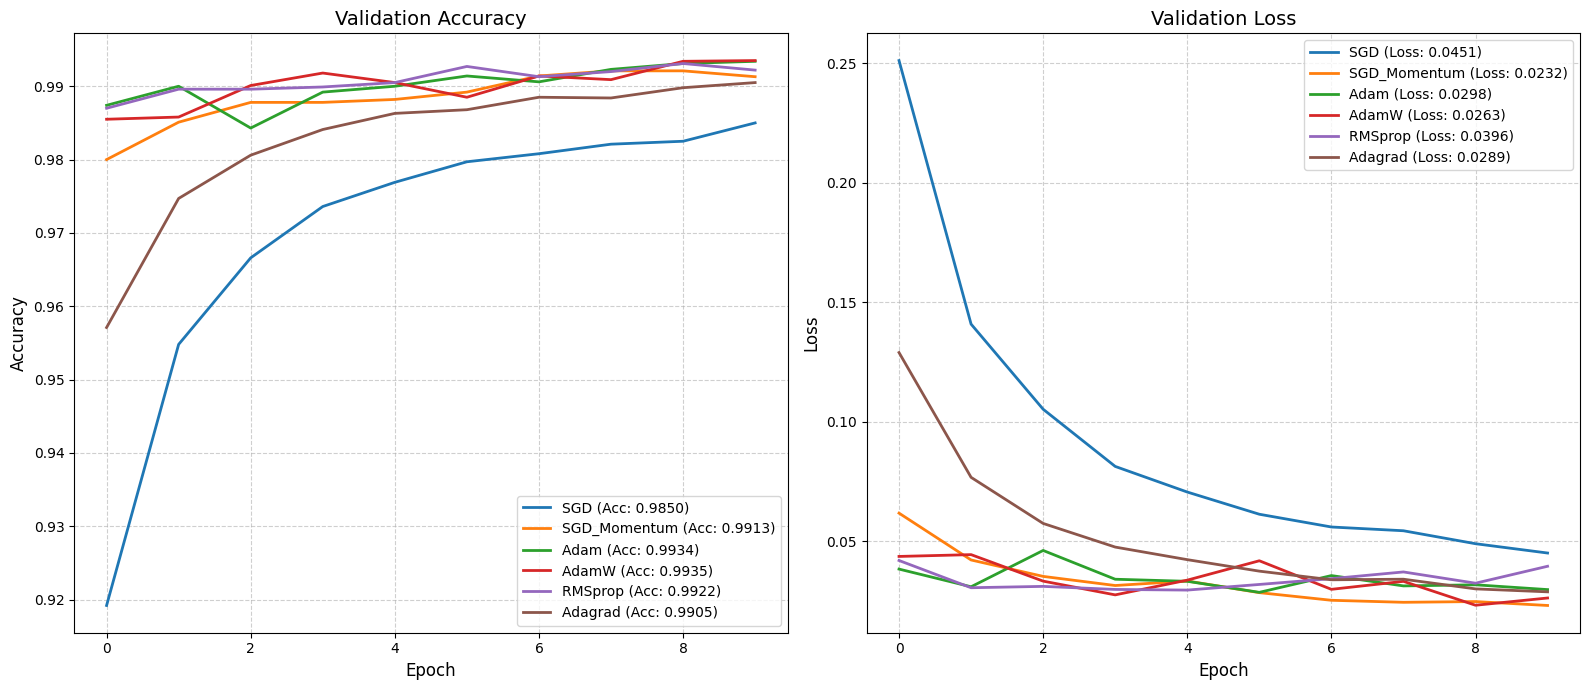

In [20]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
for name, res in results.items():
    plt.plot(res['history']['val_accuracy'], label=f"{name} (Acc: {res['test_acc']:.4f})", linewidth=2)

plt.title('Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
for name, res in results.items():
    plt.plot(res['history']['val_loss'], label=f"{name} (Loss: {res['test_loss']:.4f})", linewidth=2)

plt.title('Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig('konacni_grafikon_optimizatora.png', dpi=300)

plt.show()

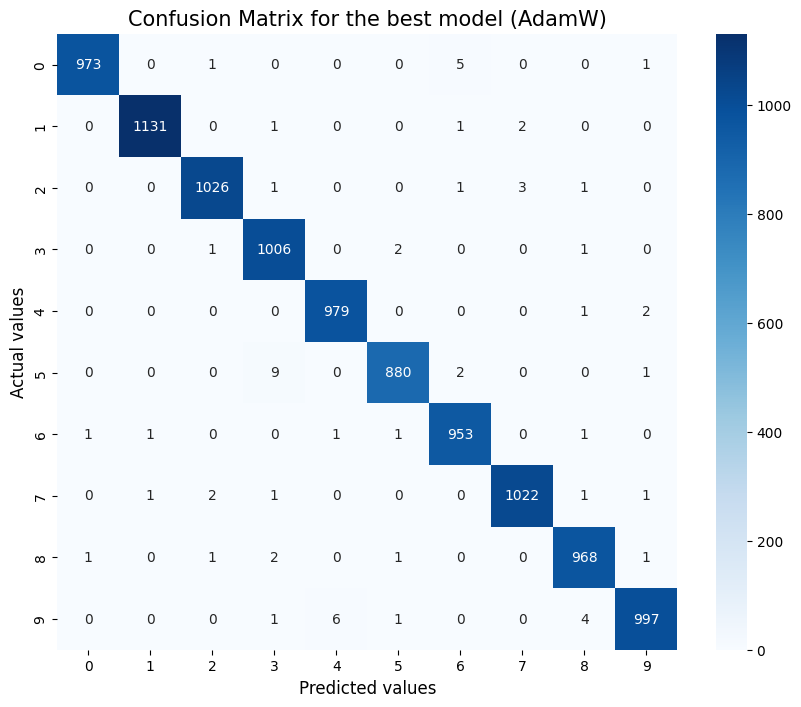

In [19]:
best_opt = max(results, key=lambda x: results[x]['test_acc'])
y_pred = results[best_opt]['y_pred']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))

plt.title(f'Confusion Matrix for the best model ({best_opt})', fontsize=15)
plt.xlabel('Predicted values', fontsize=12)
plt.ylabel('Actual values', fontsize=12)
plt.savefig('matrica_konfuzije.png', dpi=300)
plt.show()

Ukupno pogrešno klasifikovanih slika: 78 od 10,000


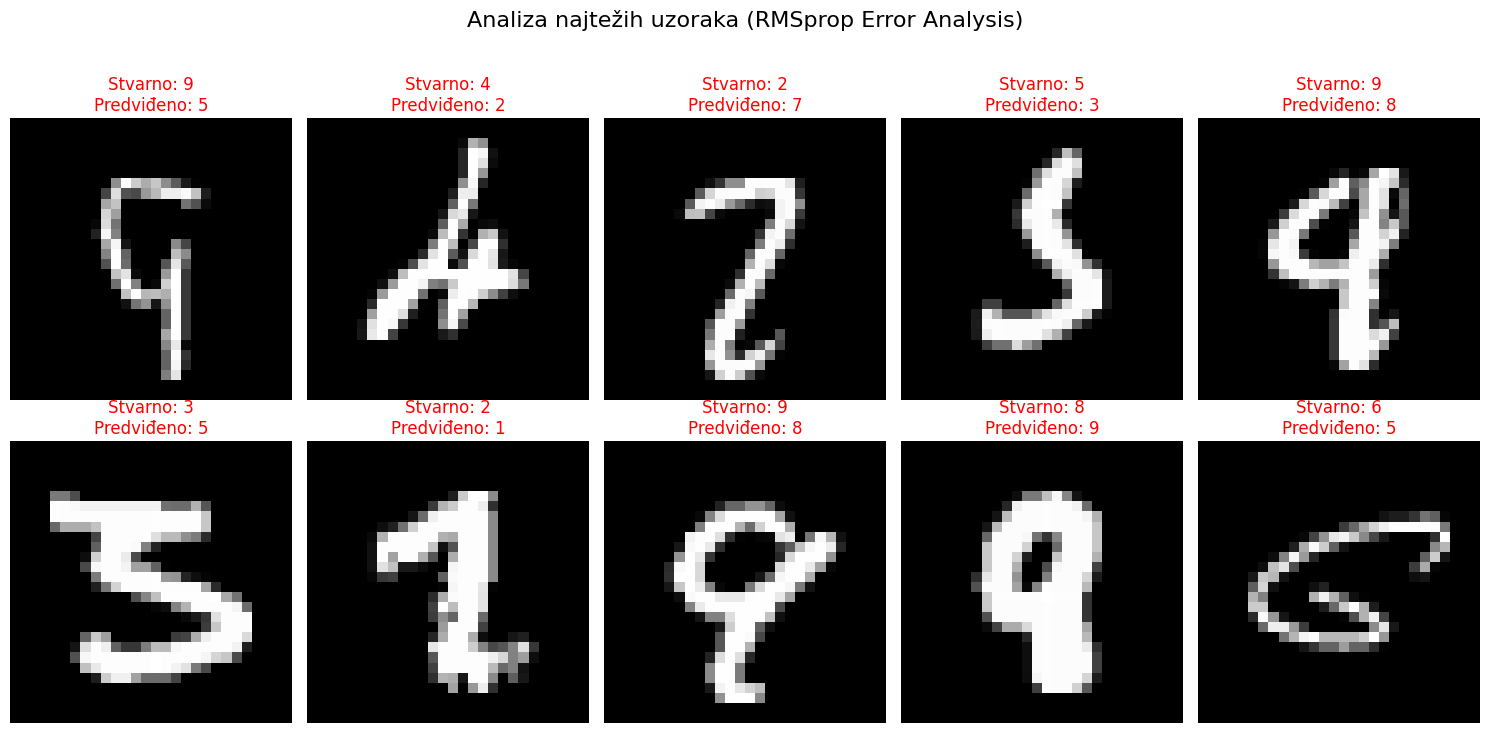

In [21]:
y_pred_best = results['RMSprop']['y_pred']

misclassified_idx = np.where(y_pred_best != y_test)[0]

print(f"Ukupno pogrešno klasifikovanih slika: {len(misclassified_idx)} od 10,000")

# 3. Vizualizacija prvih 10 grešaka
plt.figure(figsize=(15, 8))
for i, idx in enumerate(misclassified_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Stvarno: {y_test[idx]}\nPredviđeno: {y_pred_best[idx]}", color='red')
    plt.axis('off')

plt.suptitle("Analiza najtežih uzoraka (RMSprop Error Analysis)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('analiza_gresaka_visual.png', dpi=300)
plt.show()